<a href="https://colab.research.google.com/github/joana-carrasco/mvp-essencia-astral/blob/main/notebook/essencia_astral.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Essência Astral - Preditor de Elemento Astrológico

Contexto do projeto - Desde a antiguidade, a astrologia divide as pessoas em quatro grandes elementos — Fogo, Terra, Ar e Água — cada um representando um conjunto de características de personalidade e comportamento.

Este projeto utiliza técnicas de Machine Learning para criar um modelo capaz de prever o elemento astrológico de uma pessoa com base em traços de personalidade e mês de nascimento.

Objetivo do projeto - Treinar e comparar diferentes algoritmos de classificação (KNN, Árvore de Decisão, Naive Bayes e SVM) para identificar qual deles melhor prediz o elemento astrológico de uma pessoa, e disponibilizar o modelo em uma aplicação web simples.

Dataset - O dataset foi criado especialmente para este projeto, composto por 200 registros com as seguintes características:
- extrovertido, emocional, logico, criativo, impulsivo, paciente, comunicativo, intuitivo — traços de personalidade (valores 0 ou 1)
- mes_nascimento** — mês de nascimento da pessoa (1 a 12)
- elemento — classe alvo: Fogo, Terra, Ar ou Água

In [ ]:
# Importação das bibliotecas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

import joblib
import warnings
warnings.filterwarnings('ignore')

print("✅ Bibliotecas importadas com sucesso!")

✅ Bibliotecas importadas com sucesso!


1. Carga dos Dados

Os dados serão carregados diretamente do repositório do GitHub,
dispensando qualquer configuração manual. O dataset contém 200 registros com traços de personalidade e o elemento astrológicos correspondente.

A separação entre treino e teste é feita pelo método holdout,
reservando 20% dos dados para teste e 80% para treino, garantindo
que o modelo seja avaliado em dados que nunca viu antes.

In [ ]:
# Dataset no GitHub
url = "https://raw.githubusercontent.com/joana-carrasco/mvp-essencia-astral/refs/heads/main/dataset_astrologia.csv"

# Carregar o dataset
df = pd.read_csv(url)

# Visualização das linhas iniciais
print(f"✅ Dataset carregado com sucesso!")
print(f"📊 Total de registros: {len(df)}")
print(f"📋 Colunas: {list(df.columns)}")
print()
df.head(10)

✅ Dataset carregado com sucesso!
📊 Total de registros: 200
📋 Colunas: ['extrovertido', 'emocional', 'logico', 'criativo', 'impulsivo', 'paciente', 'comunicativo', 'intuitivo', 'mes_nascimento', 'elemento']



,extrovertido,emocional,logico,criativo,impulsivo,paciente,comunicativo,intuitivo,mes_nascimento,elemento
0,0,0,1,1,0,1,1,0,6,Ar
1,0,1,0,1,1,0,1,0,4,Fogo
2,0,0,0,0,0,1,1,1,5,Ar
3,1,0,0,1,1,1,1,0,11,Fogo
4,0,0,0,1,0,0,1,1,2,Agua
5,0,1,0,1,1,1,0,1,6,Agua
6,1,0,0,1,1,0,1,1,11,Fogo
7,1,1,1,0,0,0,1,0,3,Fogo
8,0,0,0,0,1,0,1,0,12,Fogo
9,1,0,0,1,1,0,1,1,4,Fogo


2. Análise Exploratória dos Dados

Antes de treinarmos qualquer modelo, é indispensavel entender os dados.
Nesta etapa verificamos a distribuição das classes, vamos identificar possíveis valores ausentes e analisarmos o comportamento das variáveis.

Uma distribuição equilibrada entre as classes é importante para
garantir que o modelo que está sendo treinado não fique "viciado" em prever sempre o mesmo elemento.

=== Informações do Dataset ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   extrovertido    200 non-null    int64 
 1   emocional       200 non-null    int64 
 2   logico          200 non-null    int64 
 3   criativo        200 non-null    int64 
 4   impulsivo       200 non-null    int64 
 5   paciente        200 non-null    int64 
 6   comunicativo    200 non-null    int64 
 7   intuitivo       200 non-null    int64 
 8   mes_nascimento  200 non-null    int64 
 9   elemento        200 non-null    object
dtypes: int64(9), object(1)
memory usage: 15.8+ KB

=== Valores Ausentes ===
extrovertido      0
emocional         0
logico            0
criativo          0
impulsivo         0
paciente          0
comunicativo      0
intuitivo         0
mes_nascimento    0
elemento          0
dtype: int64

=== Distribuição dos Elementos ===
elemento
A

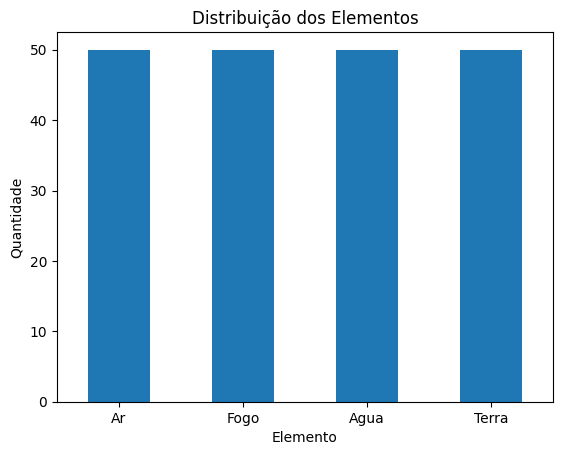

In [ ]:
# Informações gerais do dataset
print("=== Informações do Dataset ===")
df.info()

# Verificando valores ausentes
print("\n=== Valores Ausentes ===")
print(df.isnull().sum())

# Distribuição dos elementos
print("\n=== Distribuição dos Elementos ===")
print(df['elemento'].value_counts())

# Gráfico simples de distribuição
df['elemento'].value_counts().plot(kind='bar')
plt.title('Distribuição dos Elementos')
plt.xlabel('Elemento')
plt.ylabel('Quantidade')
plt.xticks(rotation=0)
plt.show()

3. Pré-processamento dos Dados

Antes do treinamento, os dados precisam ser preparados.
Nesta etapa vamos realizar duas transformações principais:

- Separação entre features e target: separamos as colunas de entrada
(características da pessoa) da coluna de saída (elemento).
- Codificação do target: convertemos os elementos (Fogo, Terra, Ar, Água)
em números, pois os algoritmos trabalham apenas com valores numéricos.
- Divisão treino/teste: separamos 80% dos dados para treino e 20% para teste.
- Normalização: aplicamos padronização nas features para que todas
as variáveis tenham a mesma escala, evitando que uma variável domine as outras.

In [ ]:
# Separando features (X) e target (y)
X = df.drop('elemento', axis=1)
y = df['elemento']

# Target em números
le = LabelEncoder()
y_encoded = le.fit_transform(y)

print("Classes identificadas:", le.classes_)
print("Exemplo de codificação:")
for i, classe in enumerate(le.classes_):
    print(f"  {classe} → {i}")

# Divisão treino e teste (80% treino, 20% teste)
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

print(f"\n✅ Divisão concluída!")
print(f"  Treino: {len(X_train)} registros")
print(f"  Teste:  {len(X_test)} registros")

Classes identificadas: ['Agua' 'Ar' 'Fogo' 'Terra']
Exemplo de codificação:
  Agua → 0
  Ar → 1
  Fogo → 2
  Terra → 3

✅ Divisão concluída!
  Treino: 160 registros
  Teste:  40 registros


4. Modelagem

Agora que já treinamos os quatro algoritmos de classificação diferentes
para descobrir qual deles melhor identifica o elemento astrológico.
Utilizaremos a pipelines que combinam a padronização dos dados com cada
algoritmo, garantindo que o pré-processamento seja aplicado corretamente.

Os algoritmos utilizados foram:
- KNN: classifica com base nos vizinhos mais próximos
- Árvore de Decisão: cria regras de decisão em formato de árvore
- Naive Bayes: usa probabilidades para classificar
- SVM: encontra a melhor fronteira entre as classes

In [ ]:
# Padronização + algoritmo
pipelines = {
    'KNN': Pipeline([
        ('scaler', StandardScaler()),
        ('modelo', KNeighborsClassifier())
    ]),
    'Arvore': Pipeline([
        ('scaler', StandardScaler()),
        ('modelo', DecisionTreeClassifier(random_state=42))
    ]),
    'Naive Bayes': Pipeline([
        ('scaler', StandardScaler()),
        ('modelo', GaussianNB())
    ]),
    'SVM': Pipeline([
        ('scaler', StandardScaler()),
        ('modelo', SVC(random_state=42))
    ])
}

# Treinando com cross-validation
print("=== Avaliação com Cross-Validation (5 folds) ===\n")
resultados = {}

for nome, pipeline in pipelines.items():
    scores = cross_val_score(pipeline, X_train, y_train, cv=5, scoring='accuracy')
    resultados[nome] = scores
    print(f"{nome}:")
    print(f"  Acurácia média: {scores.mean():.4f}")
    print(f"  Desvio padrão:  {scores.std():.4f}")
    print()

print("✅ Treinamento concluído!")

=== Avaliação com Cross-Validation (5 folds) ===

KNN:
  Acurácia média: 0.5687
  Desvio padrão:  0.0606

Arvore:
  Acurácia média: 0.5563
  Desvio padrão:  0.0573

Naive Bayes:
  Acurácia média: 0.5687
  Desvio padrão:  0.0848

SVM:
  Acurácia média: 0.5563
  Desvio padrão:  0.0500

✅ Treinamento concluído!


5. Otimização - Hiperparâmetros

Para fazer com que o modelo fique mais eficaz aplicamos a técnica de
GridSearchCV, que testa automaticamente diferentes combinações de
parâmetros e encontra a configuração que gera o melhor resultado.

In [ ]:
# Definindo os parâmetros a serem testados
params = {
    'KNN': {
        'modelo__n_neighbors': [3, 5, 7, 9],
        'modelo__weights': ['uniform', 'distance']
    },
    'Arvore': {
        'modelo__max_depth': [3, 5, 7, None],
        'modelo__criterion': ['gini', 'entropy']
    },
    'Naive Bayes': {
        'modelo__var_smoothing': [1e-9, 1e-8, 1e-7]
    },
    'SVM': {
        'modelo__C': [0.1, 1, 10],
        'modelo__kernel': ['linear', 'rbf']
    }
}

# Executando o GridSearchCV
print("=== Otimização de Hiperparâmetros ===\n")
melhores_modelos = {}

for nome, pipeline in pipelines.items():
    grid = GridSearchCV(pipeline, params[nome], cv=5, scoring='accuracy')
    grid.fit(X_train, y_train)
    melhores_modelos[nome] = grid.best_estimator_
    print(f"{nome}:")
    print(f"  Melhores parâmetros: {grid.best_params_}")
    print(f"  Melhor acurácia:     {grid.best_score_:.4f}")
    print()

print("✅ Otimização concluída!")

=== Otimização de Hiperparâmetros ===

KNN:
  Melhores parâmetros: {'modelo__n_neighbors': 5, 'modelo__weights': 'distance'}
  Melhor acurácia:     0.5813

Arvore:
  Melhores parâmetros: {'modelo__criterion': 'entropy', 'modelo__max_depth': None}
  Melhor acurácia:     0.6375

Naive Bayes:
  Melhores parâmetros: {'modelo__var_smoothing': 1e-09}
  Melhor acurácia:     0.5687

SVM:
  Melhores parâmetros: {'modelo__C': 0.1, 'modelo__kernel': 'rbf'}
  Melhor acurácia:     0.6062

✅ Otimização concluída!


6. Avaliação e Comparação dos Modelos

Agora vamos avaliar o desempenho final de cada modelo nos dados
de teste. Utilizamos métricas como acurácia, precisão, recall e F1-score para uma análise completa do desempenho.

In [ ]:
# Avaliação final do
print("=== Avaliação Final nos Dados de Teste ===\n")

for nome, modelo in melhores_modelos.items():
    y_pred = modelo.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    print(f"{'='*40}")
    print(f"Modelo: {nome}")
    print(f"Acurácia no teste: {acc:.4f}")
    print(f"\nRelatório detalhado:")
    print(classification_report(y_test, y_pred, target_names=le.classes_))

# Comparação visual
print("\n=== Resumo Comparativo ===")
print(f"{'Modelo':<15} {'Acurácia':<10}")
print("-" * 25)
for nome, modelo in melhores_modelos.items():
    y_pred = modelo.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    print(f"{nome:<15} {acc:.4f}")

=== Avaliação Final nos Dados de Teste ===

Modelo: KNN
Acurácia no teste: 0.4750

Relatório detalhado:
              precision    recall  f1-score   support

        Agua       0.50      0.60      0.55        10
          Ar       0.43      0.30      0.35        10
        Fogo       0.36      0.50      0.42        10
       Terra       0.71      0.50      0.59        10

    accuracy                           0.47        40
   macro avg       0.50      0.47      0.48        40
weighted avg       0.50      0.47      0.48        40

Modelo: Arvore
Acurácia no teste: 0.6000

Relatório detalhado:
              precision    recall  f1-score   support

        Agua       0.38      0.30      0.33        10
          Ar       0.64      0.70      0.67        10
        Fogo       0.64      0.70      0.67        10
       Terra       0.70      0.70      0.70        10

    accuracy                           0.60        40
   macro avg       0.59      0.60      0.59        40
weighted avg      

7. Exportação do Modelo

O modelo com melhor desempenho foi a Árvore de Decisão com 60% de
acurácia. Agora é exportado em formato .pkl utilizando a biblioteca joblib. Este arquivo será carregado pela aplicação back-end para realizar
novas predições sem precisar treinar o modelo novamente.

In [ ]:
# Exportando Árvore de Decisão
modelo_final = melhores_modelos['Arvore']

# Salvando o modelo e o encoder
joblib.dump(modelo_final, 'modelo_essencia_astral.pkl')
joblib.dump(le, 'encoder_elementos.pkl')

print("Modelo exportado com sucesso!")
print("Arquivos gerados:")
print("   - modelo_essencia_astral.pkl")
print("   - encoder_elementos.pkl")

Modelo exportado com sucesso!
Arquivos gerados:
   - modelo_essencia_astral.pkl
   - encoder_elementos.pkl


8. Conclusão

Na essencia astral desenvolvi um modelo de Machine Learning capaz de
prever o elemento astrológico de uma pessoa com base em traços de
personalidade e mês de nascimento.

Após testar quatro algoritmos diferentes, a Árvore de Decisão se
destacou com 60% de acurácia, mais que o dobro dos 25% esperados
por acaso com 4 classes. A otimização de hiperparâmetros contribuiu
para melhorar os resultados, especialmente na Árvore de Decisão
que subiu de 55% para 63% durante o cross-validation.

Como ponto de atenção, o dataset simples e ficticio apenas com 200 registros limita o potencial do modelo. Com dados reais e mais variáveis de personalidade,a acurácia tenderia a ser significativamente maior.

O modelo final foi exportado e integrado a uma aplicação web que
permite ao usuário descobrir seu elemento astrológico de forma
simples e interativa.